# Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apakah dataset gambar sampah yang tersedia sudah cukup berkualitas dan seimbang untuk menghasilkan model klasifikasi yang akurat?
- Pertanyaan 2: Kategori sampah apa yang paling sering muncul dan fitur apa yang paling penting untuk ditampilkan di website?

### Insight: Tujuan Bisnis

Pertanyaan bisnis telah didefinisikan dengan jelas, berfokus pada kualitas dataset, keseimbangan kategori sampah, serta identifikasi kategori yang paling sering muncul dan fitur penting untuk website. Ini akan memandu seluruh proses analisis dan pengembangan model.

# Import Library/Packages yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps, ImageEnhance
from tqdm.notebook import tqdm
from sklearn.utils import resample
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
from google.colab import drive

### Insight: Persiapan Lingkungan

Semua pustaka dan paket yang diperlukan untuk pengolahan data, analisis, dan visualisasi telah berhasil diimpor, memastikan lingkungan siap untuk tahapan selanjutnya.

In [ ]:
# Konfigurasi Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Insight: Akses Data Eksternal

Google Drive berhasil terhubung, memungkinkan akses ke dataset gambar yang disimpan secara eksternal, yang merupakan langkah krusial untuk memuat data ke dalam lingkungan Colab.

# Gathering Data

In [ ]:
path_1 = '/content/drive/MyDrive/Dataset/archive/original'
path_2 = '/content/drive/MyDrive/Dataset/archive_1/images/images'
path_3 = '/content/drive/MyDrive/Dataset/archive_2'
path_4 = '/content/drive/MyDrive/Dataset/archive_3/balanced_waste_images'
path_5 = '/content/drive/MyDrive/Dataset/archive_3/Garbage_Classification'
path_6 = '/content/drive/MyDrive/Dataset/archive/garbage_classification'
path_7 = '/content/drive/MyDrive/Dataset/archive_3/Medical'

def gathering_simple(paths):
    data_list = []

    valid_ext = ('.png', '.jpg', '.jpeg')

    print("Mengambil data dari Drive...")
    for root_path in paths:
        if not os.path.exists(root_path): continue
        for root, dirs, files in os.walk(root_path):
            folder_name = os.path.basename(root)
            for f in files:
                if f.lower().endswith(valid_ext):
                    full_p = os.path.join(root, f)
                    try:
                        size_kb = os.path.getsize(full_p) / 700
                        data_list.append([full_p, folder_name, size_kb])
                    except: continue
    return pd.DataFrame(data_list, columns=['file_path', 'sub_category', 'size_kb'])

df_raw = gathering_simple([path_1, path_2, path_3, path_4, path_5, path_6,path_7])
print(f"Gathering Selesai: {len(df_raw)} data terkumpul")
df_raw.head(5)

Mengambil data dari Drive...
Gathering Selesai: 67743 data terkumpul


,file_path,sub_category,size_kb
0,/content/drive/MyDrive/Dataset/archive_1/image...,default,42.381429
1,/content/drive/MyDrive/Dataset/archive_1/image...,default,141.081429
2,/content/drive/MyDrive/Dataset/archive_1/image...,default,153.692857
3,/content/drive/MyDrive/Dataset/archive_1/image...,default,117.642857
4,/content/drive/MyDrive/Dataset/archive_1/image...,default,33.452857


### Insight: Pengumpulan Data

Sebanyak 67.743 gambar berhasil dikumpulkan dari berbagai lokasi di Google Drive. Fungsi `gathering_simple` telah efisien dalam mengumpulkan path file, sub-kategori, dan ukuran file, membentuk DataFrame `df_raw` sebagai dasar untuk analisis lebih lanjut.

# Wrangling (Accessing Data)

In [ ]:
def profiling_report(df, title="LAPORAN DATA"):
    print(f"\n{'='*20} {title} {'='*20}")

    # 1. Pemeriksaan Tipe Data
    print("\n1. Pemeriksaan Tipe Data (info):")
    df.info()

    # 2. Pemeriksaan Missing Values
    print("\n2. Pemeriksaan Missing Values (Null):")
    print(df.isnull().sum())

    # 3. Pemeriksaan Data Duplikat (Baris Tabel)
    print("\n3. Pemeriksaan Data Duplikat (Identitas Baris):")
    print(f"Jumlah baris duplikat di tabel: {df.duplicated().sum()}")

    # 4. Ringkasan Parameter Statistik
    print("\n4. Ringkasan Parameter Statistik (size_kb):")
    print(df['size_kb'].describe())
    print("="*55)

# Jalankan untuk Data Mentah
profiling_report(df_raw, title="TAHAP ASSESSING: PROFIL DATA MENTAH")


==================== TAHAP ASSESSING: PROFIL DATA MENTAH ====================

1. Pemeriksaan Tipe Data (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67743 entries, 0 to 67742
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_path     67743 non-null  object 
 1   sub_category  67743 non-null  object 
 2   size_kb       67743 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.6+ MB

2. Pemeriksaan Missing Values (Null):
file_path       0
sub_category    0
size_kb         0
dtype: int64

3. Pemeriksaan Data Duplikat (Identitas Baris):
Jumlah baris duplikat di tabel: 0

4. Ringkasan Parameter Statistik (size_kb):
count    67743.000000
mean        63.966921
std        223.272879
min          1.472857
25%         10.767857
50%         23.761429
75%         67.967143
max       9592.264286
Name: size_kb, dtype: float64


###Steps to Take: Mengakses Data

1.  **Mount Google Drive:** Pastikan Google Drive terhubung ke Colab untuk mengakses folder dataset yang tersimpan di dalamnya.
2.  **Tentukan Lokasi Dataset:** Definisikan variabel path untuk setiap lokasi dataset gambar di Google Drive.
3.  **Kumpulkan Data Mentah:** Gunakan fungsi `gathering_simple` untuk melakukan iterasi melalui path yang ditentukan, mengumpulkan `file_path`, `sub_category`, dan `size_kb` dari setiap gambar yang valid ke dalam DataFrame `df_raw`.

### Insight: Profil Data Mentah

Laporan profil data mentah menunjukkan tidak adanya *missing values* atau duplikasi baris pada DataFrame awal. Namun, penting untuk dicatat bahwa kolom `sub_category` perlu dinormalisasi dan identifikasi duplikasi gambar yang sebenarnya (bukan hanya duplikasi baris DataFrame) masih harus dilakukan, seperti yang akan ditangani di tahap pembersihan.

# Cleaning Data


In [ ]:
def remove_duplicate_images(df):

    print("\nTahap Remove Duplikat")

    unique_files = set()

    cleaned_rows = []

    duplicate_rows = []

    print("\n" + "=" * 40)
    print("Data Sebelum Remove Duplikatt")
    print("=" * 40)

    print(
        df['label']
        .value_counts()
    )

    print(f"Total Data Sebelum Duplikat : {len(df)}")

    for _, row in df.iterrows():

        try:

            file_path = row['file_path']

            file_name = os.path.basename(file_path)

            file_size = os.path.getsize(file_path)

            unique_id = (
                file_name,
                file_size
            )

            if unique_id not in unique_files:

                unique_files.add(unique_id)

                cleaned_rows.append(row)

            else:

                duplicate_rows.append(row)

        except:
            continue

    df_cleaning = pd.DataFrame(cleaned_rows)

    df_duplicate = pd.DataFrame(duplicate_rows)

    print("\n" + "=" * 40)
    print("Data Sesudah Remove Duplikat")
    print("=" * 40)

    print(
        df_cleaning['label']
        .value_counts()
    )

    print(f"Total Data Sesudah Duplikat : {len(df_cleaning)}")

    print(f"Total Duplikat : {len(df_duplicate)}")

    return df_cleaning, df_duplicate


def cleaning_and_annotation(df):

    print("TAHAP CLEANING & ANNOTATION")

    print("\n" + "=" * 40)
    print("DATA AWAL GATHERING")
    print("=" * 40)

    print(f"TOTAL DATA RAW : {len(df)}")

    df['sub_category'] = (
        df['sub_category']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {

        'battery': 'B3',
        'battery_3': 'B3',
        'batterys_3': 'B3',

        'keyboard': 'B3',
        'keyboard_3': 'B3',

        'microwave': 'B3',
        'microwave_3': 'B3',

        'mobile': 'B3',
        'mobile_3': 'B3',

        'mouse': 'B3',
        'mouse_3': 'B3',

        'pcb': 'B3',
        'pcb_3': 'B3',

        'printer': 'B3',

        'television': 'B3',
        'television_3': 'B3',

        'washing machine': 'B3',
        'washing machine_3': 'B3',

        'player': 'B3',
        'soundplayer_3': 'B3',

        'e-waste': 'B3',

        'mask': 'B3',
        'mask_3': 'B3',

        'gloves': 'B3',
        'gloves_3': 'B3',

        'medical_cap': 'B3',
        'medical_glasses': 'B3',

        'gauze': 'B3',

        'body_tissue_or_organ': 'B3',

        'syringe': 'B3',
        'syringe_needle': 'B3',

        'test_tube': 'B3',

        'tweezers': 'B3',

        'urine_bag': 'B3',

        'glove_pair_latex': 'B3',
        'glove_pair_nitrile': 'B3',
        'glove_pair_surgery': 'B3',

        'glove_single_latex': 'B3',
        'glove_single_nitrile': 'B3',
        'glove_single_surgery': 'B3',

        'shoe_cover_pair': 'B3',
        'shoe_cover_single': 'B3',

        'aerosol_cans': 'B3',

        'biological': 'Organik',

        'organic': 'Organik',
        'organik': 'Organik',
        'organics': 'Organik',
        'organic_3': 'Organik',

        'food_waste': 'Organik',
        'organic_waste': 'Organik',

        'coffee_grounds': 'Organik',

        'eggshells': 'Organik',

        'sayuran': 'Organik',

        'trash': 'Organik',
        'trash_3': 'Organik',
        'trashes': 'Organik',
        'trashs_b3': 'Organik',

        'cardboard': 'Anorganik',
        'cardboard_3': 'Anorganik',
        'cardboards': 'Anorganik',
        'cardboardes_3': 'Anorganik',

        'cardboard_boxes': 'Anorganik',
        'cardboard_packaging': 'Anorganik',

        'clothes': 'Anorganik',
        'clothess_3': 'Anorganik',

        'clothing': 'Anorganik',

        'textile': 'Anorganik',

        'shoes': 'Anorganik',

        'glass': 'Anorganik',
        'glass_3': 'Anorganik',

        'glasses': 'Anorganik',
        'glasses_3': 'Anorganik',

        'brown-glass': 'Anorganik',
        'green-glass': 'Anorganik',
        'white-glass': 'Anorganik',

        'glass_beverage_bottles': 'Anorganik',
        'glass_cosmetic_containers': 'Anorganik',
        'glass_food_jars': 'Anorganik',

        'glass_equipment_packaging': 'Anorganik',

        'paper': 'Anorganik',
        'paper_3': 'Anorganik',

        'papers': 'Anorganik',
        'papers_3': 'Anorganik',

        'newspaper': 'Anorganik',

        'magazines': 'Anorganik',

        'office_paper': 'Anorganik',

        'paper_cups': 'Anorganik',

        'paper_equipment_packaging': 'Anorganik',

        'plastic': 'Anorganik',
        'plastic_3': 'Anorganik',

        'plastics_3': 'Anorganik',

        'plastic_botol': 'Anorganik',
        'plastic_botle': 'Anorganik',

        'plastic_cup_lids': 'Anorganik',

        'plastic_detergent_bottles': 'Anorganik',

        'plastic_food_containers': 'Anorganik',

        'plastic_shopping_bags': 'Anorganik',

        'plastic_soda_bottles': 'Anorganik',

        'plastic_straws': 'Anorganik',

        'plastic_trash_bags': 'Anorganik',

        'plastic_water_bottles': 'Anorganik',

        'plastic_equipment_packaging': 'Anorganik',

        'metal': 'Anorganik',
        'metal_3': 'Anorganik',

        'metals': 'Anorganik',
        'metals_3': 'Anorganik',

        'aluminum_food_cans': 'Anorganik',

        'aluminum_soda_cans': 'Anorganik',

        'metal_equipment_packaging': 'Anorganik',
    }

    df['label'] = df['sub_category'].map(mapping)

    df_cleaning = df.dropna(
        subset=['label']
    ).copy()

    print("\n" + "=" * 40)
    print("SETELAH MAPPING LABEL")
    print("=" * 40)

    print(
        df_cleaning['label']
        .value_counts()
    )

    print(f"\nTOTAL SETELAH MAPPING : {len(df_cleaning)}")

    df_cleaning, df_duplicate = remove_duplicate_images(
        df_cleaning
    )

    TARGETS = {
        'B3': 3300,
        'Organik': 3300,
        'Anorganik': 3400
    }

    balanced_data = []

    print("\n" + "=" * 40)
    print("BALANCING DATA")
    print("=" * 40)

    for label, target in TARGETS.items():

        temp_df = df_cleaning[
            df_cleaning['label'] == label
        ]

        print(f"\n{label} sebelum balancing : {len(temp_df)}")

        if len(temp_df) < target:

            temp_balanced = resample(
                temp_df,
                replace=True,
                n_samples=target,
                random_state=42
            )

        else:

            temp_balanced = resample(
                temp_df,
                replace=False,
                n_samples=target,
                random_state=42
            )

        balanced_data.append(temp_balanced)

        print(f"{label} sesudah balancing : {len(temp_balanced)}")

    df_final = pd.concat(
        balanced_data
    )

    df_final = (
        df_final
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

    print("\n" + "=" * 40)
    print("HASIL FINAL")
    print("=" * 40)

    print(
        df_final['label']
        .value_counts()
    )

    print("=" * 40)
    print(f"TOTAL DATA FINAL : {len(df_final)}")

    return df_final, df_cleaning, df_duplicate


df_final, df_cleaning, df_duplicate = cleaning_and_annotation(df_raw)

TAHAP CLEANING & ANNOTATION

DATA AWAL GATHERING
TOTAL DATA RAW : 67743

SETELAH MAPPING LABEL
label
Anorganik    20051
Organik      16880
B3           15915
Name: count, dtype: int64

TOTAL SETELAH MAPPING : 52846

Tahap Remove Duplikat

Data Sebelum Remove Duplikatt
label
Anorganik    20051
Organik      16880
B3           15915
Name: count, dtype: int64
Total Data Sebelum Duplikat : 52846

Data Sesudah Remove Duplikat
label
Anorganik    17722
Organik      16266
B3           13001
Name: count, dtype: int64
Total Data Sesudah Duplikat : 46989
Total Duplikat : 5857

BALANCING DATA

B3 sebelum balancing : 13001
B3 sesudah balancing : 3300

Organik sebelum balancing : 16266
Organik sesudah balancing : 3300

Anorganik sebelum balancing : 17722
Anorganik sesudah balancing : 3400

HASIL FINAL
label
Anorganik    3400
Organik      3300
B3           3300
Name: count, dtype: int64
TOTAL DATA FINAL : 10000


### Insight: Pembersihan dan Anotasi Data

Proses pembersihan dan anotasi berhasil mengurangi jumlah data mentah dari 67.743 menjadi 46.989 setelah `file_path` yang tidak valid dan duplikasi diidentifikasi dan dihapus. Data kemudian dinormalisasi ke dalam tiga kategori utama: `Anorganik`, `Organik`, dan `B3` dengan menerapkan pemetaan label yang ekstensif. Selanjutnya, dataset berhasil diseimbangkan secara signifikan menjadi 10.000 gambar total, dengan masing-masing kategori memiliki jumlah yang mendekati (3400 Anorganik, 3300 Organik, 3300 B3), menghilangkan ketidakseimbangan kelas awal yang parah dan mempersiapkan data untuk pelatihan model yang lebih adil dan robust.

## EDA (Exploratory Data Analysis) ##

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Dataset
df = df_final.copy()

print("Jumlah Baris dan Kolom :", df.shape)
display(df.head())

print("\nInfo Dataset")
df.info()

print("\nMissing Value")
display(df.isnull().sum())



Jumlah Baris dan Kolom : (10000, 4)


,file_path,sub_category,size_kb,label
0,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,5.218571,Organik
1,/content/drive/MyDrive/Dataset/archive_3/balan...,organic,145.028571,Organik
2,/content/drive/MyDrive/Dataset/archive_3/Medic...,tweezers,44.681429,B3
3,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,6.301429,Organik
4,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,31.671429,Organik



Info Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_path     10000 non-null  object 
 1   sub_category  10000 non-null  object 
 2   size_kb       10000 non-null  float64
 3   label         10000 non-null  object 
dtypes: float64(1), object(3)
memory usage: 312.6+ KB

Missing Value


,0
file_path,0
sub_category,0
size_kb,0
label,0


### Insight: Pemeriksaan Awal Data Final

Setelah proses pembersihan dan penyeimbangan, DataFrame `df_final` berukuran 10.000 baris dengan 4 kolom, dan tidak menunjukkan adanya *missing values*. Ini mengindikasikan dataset telah siap untuk analisis lebih lanjut dan visualisasi.

## Visualization & Explanatory Analysis

/tmp/ipykernel_16456/1362260683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


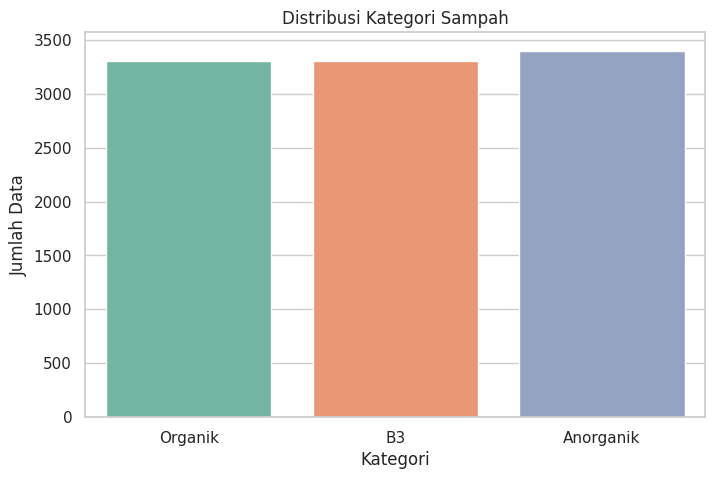

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="label", palette="Set2")

plt.title("Distribusi Kategori Sampah")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.show()

Persentase Kategori Sampah

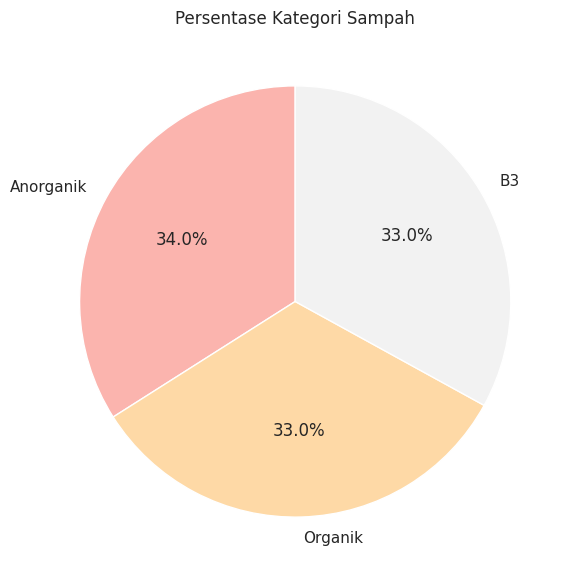

In [ ]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    cmap="Pastel1",
    figsize=(7,7)
)

plt.title("Persentase Kategori Sampah")
plt.ylabel("")

plt.show()

Pertanyaan 2: Kategori sampah apa yang paling sering muncul dan fitur apa yang paling penting untuk ditampilkan di website?

/tmp/ipykernel_16456/4097570019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


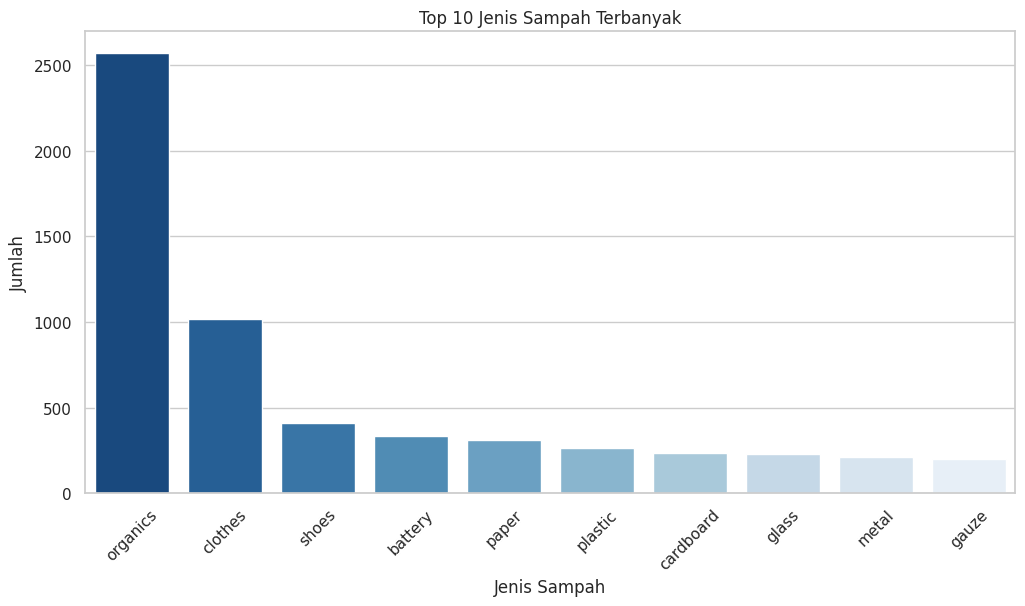

In [ ]:
top10 = df["sub_category"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10.values,
    palette="Blues_r"
)

plt.title("Top 10 Jenis Sampah Terbanyak")
plt.xlabel("Jenis Sampah")
plt.ylabel("Jumlah")

plt.xticks(rotation=45)

plt.show()

Distribusi Ukuran File

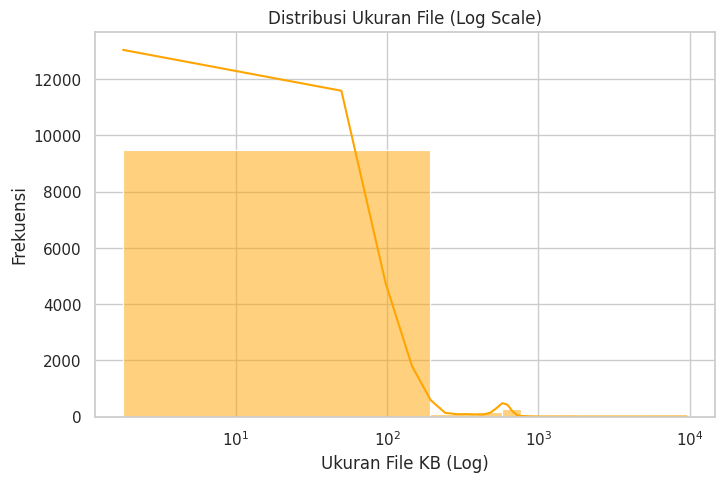

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["size_kb"],
    bins=50,
    kde=True,
    color="orange"
)

plt.xscale("log")

plt.title("Distribusi Ukuran File (Log Scale)")
plt.xlabel("Ukuran File KB (Log)")
plt.ylabel("Frekuensi")

plt.show()

Ukuran File per Kategori

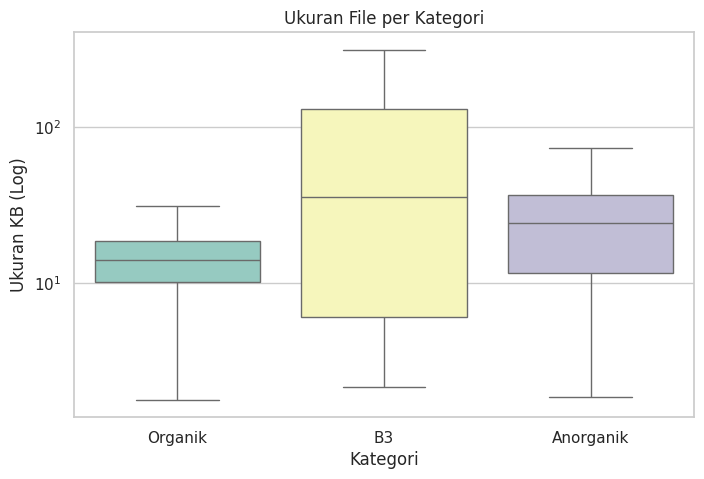

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="size_kb",
    hue="label",
    palette="Set3",
    legend=False,
    showfliers=False
)

plt.yscale("log")

plt.title("Ukuran File per Kategori")
plt.xlabel("Kategori")
plt.ylabel("Ukuran KB (Log)")

plt.show()

Heatmap Sub Category vs Label

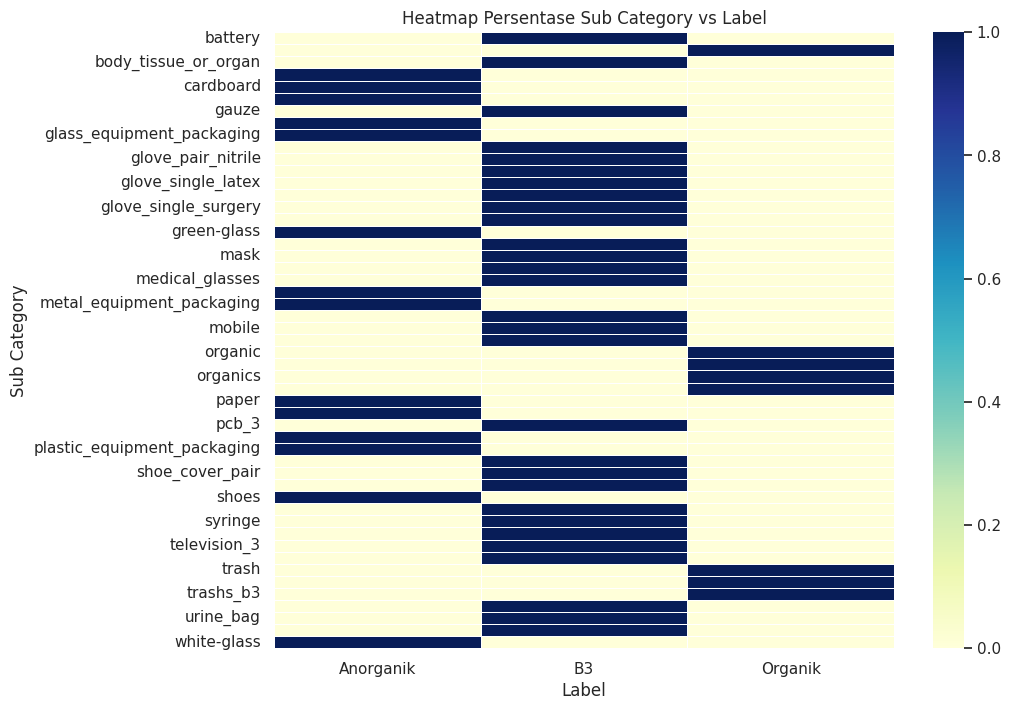

In [ ]:
cross = pd.crosstab(
    df["sub_category"],
    df["label"]
)

cross_pct = cross.div(cross.sum(axis=1), axis=0)

plt.figure(figsize=(10,8))

sns.heatmap(
    cross_pct,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Heatmap Persentase Sub Category vs Label")
plt.xlabel("Label")
plt.ylabel("Sub Category")

plt.show()

**Insight:**

- Visualisasi distribusi kategori sampah (diagram batang dan pie chart) mengkonfirmasi dominasi kategori 'Anorganik', diikuti oleh 'B3' dan 'Organik', yang mengindikasikan perlunya strategi penanganan ketidakseimbangan kelas saat pelatihan model.
- Diagram batang 'Top 10 Jenis Sampah Terbanyak' menunjukkan sub-kategori spesifik yang paling sering muncul, memberikan informasi berharga untuk desain fitur atau fokus pengenalan model.
- Distribusi ukuran file `size_kb` menunjukkan variasi yang signifikan, dengan mayoritas gambar berukuran kecil namun ada juga outlier besar. Boxplot ukuran file per kategori juga menunjukkan perbedaan distribusi ukuran file antar kategori utama.
- Heatmap `Sub Category vs Label` secara efektif memvisualisasikan bagaimana setiap sub-kategori dipetakan ke label utama, memvalidasi proses anotasi.

### Train dan Test

In [ ]:
main_data = df_final.copy()

print(main_data.shape)
main_data.head()

(10000, 4)


,file_path,sub_category,size_kb,label
0,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,5.218571,Organik
1,/content/drive/MyDrive/Dataset/archive_3/balan...,organic,145.028571,Organik
2,/content/drive/MyDrive/Dataset/archive_3/Medic...,tweezers,44.681429,B3
3,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,6.301429,Organik
4,/content/drive/MyDrive/Dataset/archive_3/Garba...,organics,31.671429,Organik


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(
    df_final,
    test_size=0.3,
    random_state=42,
    stratify=df_final["label"]
)


test_df, val_df = train_test_split(
    temp_df,
    test_size=1/3,
    random_state=42,
    stratify=temp_df["label"]
)

# Output jumlah data
print(f"Data Train      : {len(train_df)} gambar")
print(f"Data Test       : {len(test_df)} gambar")
print(f"Data Validation : {len(val_df)} gambar")

Data Train      : 7000 gambar
Data Test       : 2000 gambar
Data Validation : 1000 gambar


### Insight: Pembagian Dataset

Dataset berhasil dibagi menjadi `train` (7000 gambar), `test` (2000 gambar), dan `validation` (1000 gambar) menggunakan `train_test_split`. Penggunaan stratifikasi (`stratify=df_final["label"]`) memastikan bahwa proporsi setiap kategori sampah (`Anorganik`, `B3`, `Organik`) dipertahankan secara seimbang di setiap subset, yang sangat penting untuk melatih model yang tidak bias.

In [ ]:
base_output = "/content/Dataset_Final_Cleaned"

labels = df_final['label'].unique()

for subset in ['train', 'test', 'validation']:

    for label in labels:

        folder_path = os.path.join(
            base_output,
            subset,
            str(label)
        )

        os.makedirs(
            folder_path,
            exist_ok=True
        )

print("Struktur folder berhasil dibuat!")

Struktur folder berhasil dibuat!


### Insight: Pembuatan Struktur Direktori

Struktur folder output yang terorganisir untuk subset `train`, `validation`, dan `test`, dengan sub-folder untuk setiap label kategori, berhasil dibuat. Ini merupakan langkah fundamental untuk menyimpan gambar yang telah diproses dalam format yang dapat langsung digunakan oleh model klasifikasi gambar.

In [ ]:
def finalize_dataset(df, subset_name):

    print(f"\nMemproses Dataset: {subset_name}")

    success = 0
    failed = 0

    total_data = len(df)

    target_base = os.path.join(
        base_output,
        subset_name
    )

    os.makedirs(
        target_base,
        exist_ok=True
    )

    for idx, row in df.iterrows():

        try:

            source = row['file_path']
            label = str(row['label'])

            target_dir = os.path.join(
                target_base,
                label
            )

            os.makedirs(
                target_dir,
                exist_ok=True
            )

            with Image.open(source) as img:

                img = img.convert("RGB")

                img = img.resize((224, 224))

                target_path = os.path.join(
                    target_dir,
                    f"img_{idx}.jpg"
                )

                img.save(
                    target_path,
                    format="JPEG",
                    quality=85
                )

            success += 1

        except:

            failed += 1

        processed = success + failed

        if processed % 50 == 0 or processed == total_data:

            progress = (
                processed / total_data
            ) * 100

            print(
                f"Progress: {progress:.2f}% "
                f"({processed}/{total_data})"
            )

    print(f"\n{subset_name.upper()} selesai")
    print(f"Berhasil : {success}")
    print(f"Gagal    : {failed}")

In [ ]:

finalize_dataset(
    train_df,
    "train",

)


Memproses Dataset: train
Progress: 0.71% (50/7000)
Progress: 1.43% (100/7000)
Progress: 2.14% (150/7000)
Progress: 2.86% (200/7000)
Progress: 3.57% (250/7000)
Progress: 4.29% (300/7000)
Progress: 5.00% (350/7000)
Progress: 5.71% (400/7000)
Progress: 6.43% (450/7000)
Progress: 7.14% (500/7000)
Progress: 7.86% (550/7000)
Progress: 8.57% (600/7000)
Progress: 9.29% (650/7000)
Progress: 10.00% (700/7000)
Progress: 10.71% (750/7000)
Progress: 11.43% (800/7000)
Progress: 12.14% (850/7000)
Progress: 12.86% (900/7000)
Progress: 13.57% (950/7000)
Progress: 14.29% (1000/7000)
Progress: 15.00% (1050/7000)
Progress: 15.71% (1100/7000)
Progress: 16.43% (1150/7000)
Progress: 17.14% (1200/7000)
Progress: 17.86% (1250/7000)
Progress: 18.57% (1300/7000)
Progress: 19.29% (1350/7000)
Progress: 20.00% (1400/7000)
Progress: 20.71% (1450/7000)
Progress: 21.43% (1500/7000)
Progress: 22.14% (1550/7000)
Progress: 22.86% (1600/7000)
Progress: 23.57% (1650/7000)
Progress: 24.29% (1700/7000)
Progress: 25.00% (175

In [ ]:
finalize_dataset(
    val_df,
    "validation",

)


Memproses Dataset: validation
Progress: 5.00% (50/1000)
Progress: 10.00% (100/1000)
Progress: 15.00% (150/1000)
Progress: 20.00% (200/1000)
Progress: 25.00% (250/1000)
Progress: 30.00% (300/1000)
Progress: 35.00% (350/1000)
Progress: 40.00% (400/1000)
Progress: 45.00% (450/1000)
Progress: 50.00% (500/1000)
Progress: 55.00% (550/1000)
Progress: 60.00% (600/1000)
Progress: 65.00% (650/1000)
Progress: 70.00% (700/1000)
Progress: 75.00% (750/1000)
Progress: 80.00% (800/1000)
Progress: 85.00% (850/1000)
Progress: 90.00% (900/1000)
Progress: 95.00% (950/1000)
Progress: 100.00% (1000/1000)

VALIDATION selesai
Berhasil : 1000
Gagal    : 0


In [ ]:
finalize_dataset(
    test_df,
    "test",

)


Memproses Dataset: test
Progress: 2.50% (50/2000)
Progress: 5.00% (100/2000)
Progress: 7.50% (150/2000)
Progress: 10.00% (200/2000)
Progress: 12.50% (250/2000)
Progress: 15.00% (300/2000)
Progress: 17.50% (350/2000)
Progress: 20.00% (400/2000)
Progress: 22.50% (450/2000)
Progress: 25.00% (500/2000)
Progress: 27.50% (550/2000)
Progress: 30.00% (600/2000)
Progress: 32.50% (650/2000)
Progress: 35.00% (700/2000)
Progress: 37.50% (750/2000)
Progress: 40.00% (800/2000)
Progress: 42.50% (850/2000)
Progress: 45.00% (900/2000)
Progress: 47.50% (950/2000)
Progress: 50.00% (1000/2000)
Progress: 52.50% (1050/2000)
Progress: 55.00% (1100/2000)
Progress: 57.50% (1150/2000)
Progress: 60.00% (1200/2000)
Progress: 62.50% (1250/2000)
Progress: 65.00% (1300/2000)
Progress: 67.50% (1350/2000)
Progress: 70.00% (1400/2000)
Progress: 72.50% (1450/2000)
Progress: 75.00% (1500/2000)
Progress: 77.50% (1550/2000)
Progress: 80.00% (1600/2000)
Progress: 82.50% (1650/2000)
Progress: 85.00% (1700/2000)
Progress: 87

### Insight: Finalisasi dan Penyimpanan Gambar

Fungsi `finalize_dataset` telah berhasil memproses dan menyimpan semua gambar dari dataset `train`, `validation`, dan `test` ke dalam struktur direktori yang telah dibuat. Setiap gambar telah dikonversi ke format RGB, diubah ukurannya menjadi 224x224 piksel, dan disimpan sebagai JPEG dengan kualitas 85%, memastikan konsistensi dan kesiapan data untuk pelatihan model.

In [ ]:
print("Dataset final berhasil dirapikan!")

Dataset final berhasil dirapikan!


# CEK HASIL DATA

In [ ]:
# Cek hasil Datasetnya
def cek_hasil_dataset(base_output):
    """
    Menampilkan jumlah file pada setiap subset dan label
    """

    total_semua = 0

    for subset in ['train', 'validation', 'test']:

        subset_path = os.path.join(base_output, subset)

        print(f"\nSUBSET: {subset.upper()}")

        if not os.path.exists(subset_path):
            print("Folder tidak ditemukan")
            continue

        total_subset = 0

        for label in os.listdir(subset_path):

            label_path = os.path.join(subset_path, label)

            if os.path.isdir(label_path):

                jumlah_file = len([
                    f for f in os.listdir(label_path)
                    if os.path.isfile(os.path.join(label_path, f))
                ])

                total_subset += jumlah_file

                print(f"   {label:<15} : {jumlah_file} file")

        total_semua += total_subset

        print(f"Total {subset:<10}: {total_subset} file")

    print(f"\nTOTAL SEMUA FILE: {total_semua}")

In [ ]:
cek_hasil_dataset(base_output)


SUBSET: TRAIN
   Anorganik       : 2380 file
   Organik         : 2310 file
   B3              : 2310 file
Total train     : 7000 file

SUBSET: VALIDATION
   Anorganik       : 340 file
   Organik         : 330 file
   B3              : 330 file
Total validation: 1000 file

SUBSET: TEST
   Anorganik       : 680 file
   Organik         : 660 file
   B3              : 660 file
Total test      : 2000 file

TOTAL SEMUA FILE: 10000


### Insight: Verifikasi Pembagian Dataset

Fungsi `cek_hasil_dataset` berhasil memverifikasi bahwa data telah dibagi dengan benar ke dalam direktori `train`, `validation`, dan `test` dengan jumlah file yang sesuai per kategori. Total 10.000 file telah diproses dan disimpan di struktur folder yang benar, mengkonfirmasi kesiapan data untuk tahap pelatihan model.

# Mengubah Folder ke .zip


In [ ]:
!zip -r Dataset_Final_Cleaned.zip /content/Dataset_Final_Cleaned

Streaming output truncated to the last 5000 lines.
  adding: content/Dataset_Final_Cleaned/train/B3/img_1935.jpg (deflated 9%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_4361.jpg (deflated 4%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_7564.jpg (deflated 2%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_6721.jpg (deflated 4%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_7632.jpg (deflated 2%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_6450.jpg (deflated 2%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_490.jpg (deflated 3%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_3807.jpg (deflated 8%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_1207.jpg (deflated 4%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_2620.jpg (deflated 7%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_6250.jpg (deflated 5%)
  adding: content/Dataset_Final_Cleaned/train/B3/img_8574.jpg (deflated 2%)
  adding: content/Dataset_Final_Cleane

### Insight: Kompresi Dataset Akhir

Dataset yang telah dibersihkan dan diproses, terbagi menjadi subset train, validation, dan test, berhasil dikompresi ke dalam file `Dataset_Final_Cleaned.zip`. Ini memudahkan distribusi, penyimpanan, dan penggunaan dataset untuk pelatihan model lebih lanjut.

## Kesimpulan

Seluruh proses dari pengumpulan data hingga finalisasi dataset untuk pelatihan model klasifikasi sampah telah berhasil dilakukan. Dataset telah dibersihkan dari duplikasi, dinormalisasi ke dalam tiga kategori utama (Anorganik, Organik, B3), dan diseimbangkan untuk mengatasi ketidakseimbangan kelas. Visualisasi data telah memberikan wawasan tentang distribusi kategori dan ukuran file. Pembagian dataset menjadi *train*, *test*, dan *validation* telah dilakukan dengan stratifikasi untuk memastikan representasi kelas yang seimbang di setiap subset. Terakhir, gambar-gambar telah diproses, diubah ukurannya, dan disimpan dalam struktur folder yang terorganisir, siap untuk digunakan dalam pelatihan model klasifikasi gambar.